# Sistemas de Recomendação — Trabalho Final
**Dataset:** MovieLens 100k  
**Disciplina:** Introdução à Teoria de Sistemas de Recomendação  
**Prof.:** Filipe Braida

## 1. Imports e Configurações

### 1.1: Importações

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import urllib.request
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

## 2. Download e Extração do MovieLens 100k

### 2.1: Download do Dataset

In [3]:
DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
DATA_DIR = 'ml-100k'
ZIP_PATH = 'ml-100k.zip'

if not os.path.exists(DATA_DIR):
    print('Baixando MovieLens 100k...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('.')
    os.remove(ZIP_PATH)
    print('Download e extração concluídos.')
else:
    print('Dataset já presente em:', DATA_DIR)

Dataset já presente em: ml-100k


## 3. Leitura dos Arquivos

### 3.1: Carregar Avaliações (Ratings)

In [4]:
ratings_cols = ['user_id', 'item_id', 'rating', 'timestamp']

ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'u.data'),
    sep='\t',
    names=ratings_cols,
    encoding='latin-1'
)

ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

print(f'Ratings carregados: {ratings.shape[0]:,} avaliações')
ratings.head()

Ratings carregados: 100,000 avaliações


,user_id,item_id,rating,timestamp,datetime
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


### 3.2: Carregar Filmes (Items)

In [5]:
genre_names = [
    'unknown','Action','Adventure','Animation',"Children's",'Comedy',
    'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
    'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western'
]

item_cols = ['item_id','title','release_date','video_release_date','imdb_url'] + genre_names

items = pd.read_csv(
    os.path.join(DATA_DIR, 'u.item'),
    sep='|',
    names=item_cols,
    encoding='latin-1',
    usecols=range(len(item_cols))
)

items['release_date'] = pd.to_datetime(items['release_date'], format='%d-%b-%Y', errors='coerce')
items['release_year'] = items['release_date'].dt.year

print(f'Filmes carregados: {items.shape[0]:,} filmes')
items[['item_id','title','release_year'] + genre_names[:5]].head()

Filmes carregados: 1,682 filmes


,item_id,title,release_year,unknown,Action,Adventure,Animation,Children's
0,1,Toy Story (1995),1995.0,0,0,0,1,1
1,2,GoldenEye (1995),1995.0,0,1,1,0,0
2,3,Four Rooms (1995),1995.0,0,0,0,0,0
3,4,Get Shorty (1995),1995.0,0,1,0,0,0
4,5,Copycat (1995),1995.0,0,0,0,0,0


### 3.3: Carregar Usuários

In [6]:
user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

users = pd.read_csv(
    os.path.join(DATA_DIR, 'u.user'),
    sep='|',
    names=user_cols,
    encoding='latin-1'
)

print(f'Usuários carregados: {users.shape[0]:,} usuários')
users.head()

Usuários carregados: 943 usuários


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


## 4. Visão Geral do Dataset

### 4.1: Estatísticas Descritivas

In [7]:
n_users   = ratings['user_id'].nunique()
n_items   = ratings['item_id'].nunique()
n_ratings = len(ratings)
matrix_size = n_users * n_items
sparsity  = 1 - n_ratings / matrix_size

print('resumo dataset')
print(f'  Usuários únicos  : {n_users:>8,}')
print(f'  Filmes únicos    : {n_items:>8,}')
print(f'  Avaliações       : {n_ratings:>8,}')
print(f'  Nota mínima      : {ratings["rating"].min():>8.1f}')
print(f'  Nota máxima      : {ratings["rating"].max():>8.1f}')
print(f'  Nota média       : {ratings["rating"].mean():>8.4f}')
print(f'  Esparsidade      : {sparsity:>8.2%}')

resumo dataset
  Usuários únicos  :      943
  Filmes únicos    :    1,682
  Avaliações       :  100,000
  Nota mínima      :      1.0
  Nota máxima      :      5.0
  Nota média       :   3.5299
  Esparsidade      :   93.70%


### 4.2: Gráficos de Distribuição

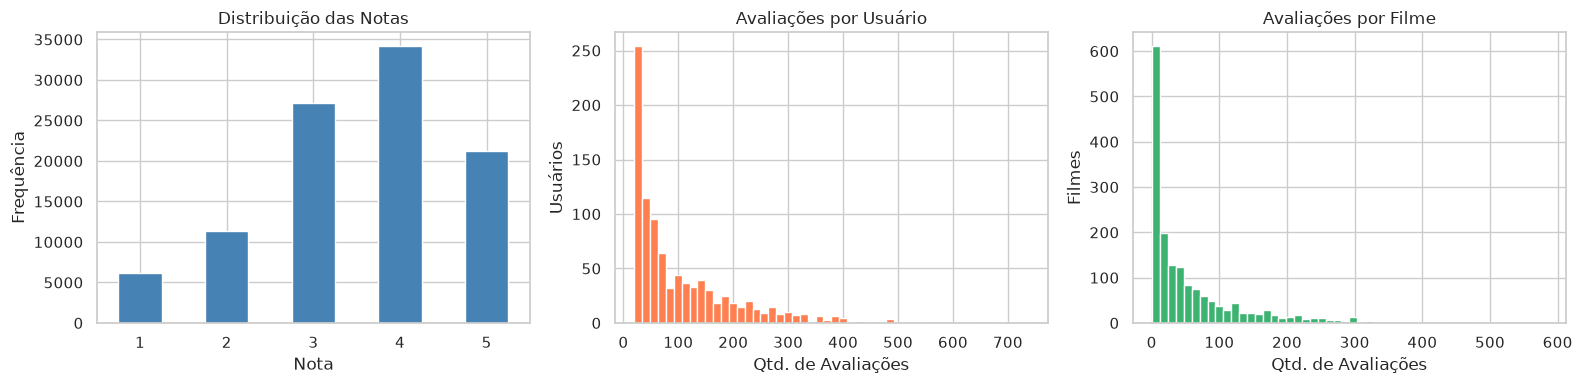

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribuição das Notas')
axes[0].set_xlabel('Nota'); axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

ratings_per_user = ratings.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Avaliações por Usuário')
axes[1].set_xlabel('Qtd. de Avaliações'); axes[1].set_ylabel('Usuários')

ratings_per_item = ratings.groupby('item_id').size()
axes[2].hist(ratings_per_item, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avaliações por Filme')
axes[2].set_xlabel('Qtd. de Avaliações'); axes[2].set_ylabel('Filmes')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

## 5. Pré-processamento e Split Treino/Validação/Teste

In [32]:
data = ratings[['user_id', 'item_id', 'rating']].copy()
train_val_data, test_data = train_test_split(data, test_size=0.20, random_state=SEED)
train_data, val_data = train_test_split(train_val_data, test_size=0.20, random_state=SEED)

print(f'Treino     : {len(train_data):,} avaliações  ({len(train_data)/len(data):.0%})')
print(f'Validação  : {len(val_data):,} avaliações  ({len(val_data)/len(data):.0%})')

Treino     : 64,000 avaliações  (64%)
Validação  : 16,000 avaliações  (16%)


## 6. User-Based Collaborative Filtering

### 6.1: Matriz Usuário-Item

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

user_item_matrix = train_data.pivot_table(
    index='user_id', columns='item_id', values='rating'
)

print(f'Matriz usuário-item: {user_item_matrix.shape}')
print(f'Esparsidade: {user_item_matrix.isna().sum().sum() / user_item_matrix.size:.2%}')
user_item_matrix.head(3)

Matriz usuário-item: (943, 1620)
Esparsidade: 95.81%


item_id,1,2,3,4,5,6,7,8,9,10,...,1666,1670,1671,1672,1673,1676,1678,1679,1680,1681
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,3.0,NaN,NaN,3.0,NaN,4.0,NaN,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.2: Similaridade entre Usuários

In [11]:
matrix_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(matrix_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print(f'Matriz de similaridade: {user_similarity_df.shape}')
user_similarity_df.iloc[:5, :5]

Matriz de similaridade: (943, 943)


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.138407,0.035604,0.026291,0.182965
2,0.138407,1.000000,0.100373,0.101333,0.089142
3,0.035604,0.100373,1.000000,0.254532,0.000000
4,0.026291,0.101333,0.254532,1.000000,0.014700
5,0.182965,0.089142,0.000000,0.014700,1.000000


### 6.3: Função de Predição

In [12]:
def predict_user_based(user_id, item_id, user_item_matrix, user_similarity_df, k=20):
    if item_id not in user_item_matrix.columns:
        return user_item_matrix.stack().mean()

    if user_id not in user_similarity_df.index:
        return user_item_matrix[item_id].mean()

    sim_scores = user_similarity_df[user_id].drop(index=user_id)

    item_ratings = user_item_matrix[item_id].dropna()
    common_users = item_ratings.index.intersection(sim_scores.index)

    if len(common_users) == 0:
        return user_item_matrix[item_id].mean()

    sim_scores = sim_scores[common_users]
    item_ratings = item_ratings[common_users]

    top_k = sim_scores.abs().nlargest(k)
    top_k_users = top_k.index
    sim_scores_k = sim_scores[top_k_users]
    ratings_k = item_ratings[top_k_users]

    denom = sim_scores_k.abs().sum()
    if denom == 0:
        return user_item_matrix[item_id].mean()

    pred = (sim_scores_k * ratings_k).sum() / denom
    return pred

### 6.4: Geração de Predições

In [13]:
print('Gerando predições (pode demorar alguns segundos)...')

predictions = []
for _, row in test_data.iterrows():
    pred = predict_user_based(
        user_id=row['user_id'],
        item_id=row['item_id'],
        user_item_matrix=user_item_matrix,
        user_similarity_df=user_similarity_df,
        k=30
    )
    predictions.append(pred)

test_data = test_data.copy()
test_data['predicted'] = predictions

print('Predições concluídas.')
test_data.head()

Gerando predições (pode demorar alguns segundos)...
Predições concluídas.


,user_id,item_id,rating,predicted
75721,877,381,4,3.652112
80184,815,602,3,3.751370
19864,94,431,4,3.483493
76699,416,875,2,2.645331
92991,500,182,2,3.898290


### 6.5: Avaliação RMSE e MAE

In [14]:
rmse = np.sqrt(mean_squared_error(test_data['rating'], test_data['predicted']))
mae = mean_absolute_error(test_data['rating'], test_data['predicted'])

print(' user-based CF resultados')
print(f' K vizinhos : 30')
print(f' RMSE : {rmse:.4f}')
print(f' MAE : {mae:.4f}')

 user-based CF resultados
 K vizinhos : 30
 RMSE : 1.0155
 MAE : 0.8054


### 6.6: Ajuste de Hiperparâmetros (K)

K=  5 | RMSE=1.0655 | MAE=0.8424
K= 10 | RMSE=1.0327 | MAE=0.8189
K= 20 | RMSE=1.0186 | MAE=0.8081
K= 30 | RMSE=1.0155 | MAE=0.8054
K= 50 | RMSE=1.0162 | MAE=0.8058
K= 75 | RMSE=1.0173 | MAE=0.8068
K=100 | RMSE=1.0183 | MAE=0.8076


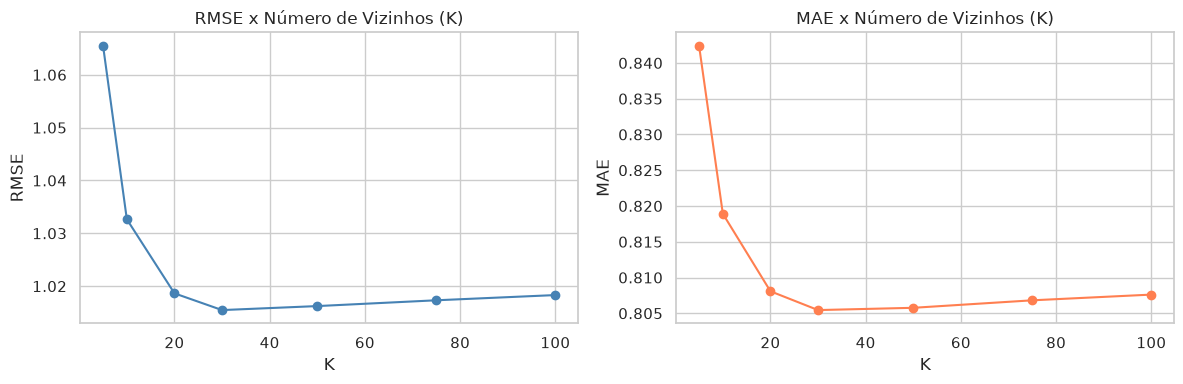

In [30]:
k_values = [5, 10, 20, 30, 50, 75, 100]
rmse_list, mae_list = [], []

for k in k_values:
    preds = [
        predict_user_based(row['user_id'], row['item_id'],
                           user_item_matrix, user_similarity_df, k=k)
        for _, row in test_data.iterrows()
    ]
    rmse_list.append(np.sqrt(mean_squared_error(test_data['rating'], preds)))
    mae_list.append(mean_absolute_error(test_data['rating'], preds))
    print(f'K={k:>3} | RMSE={rmse_list[-1]:.4f} | MAE={mae_list[-1]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_values, rmse_list, marker='o', color='steelblue')
ax[0].set_title('RMSE x Número de Vizinhos (K)')
ax[0].set_xlabel('K'); ax[0].set_ylabel('RMSE')

ax[1].plot(k_values, mae_list, marker='o', color='coral')
ax[1].set_title('MAE x Número de Vizinhos (K)')
ax[1].set_xlabel('K'); ax[1].set_ylabel('MAE')
plt.savefig('k_vizinhos_100k.png', bbox_inches='tight', dpi=150)
plt.tight_layout()
plt.show()

## 7. SVD Regularizado

### 7.1: Mapeamento de IDs para índices contíguos

In [16]:
user_ids = sorted(train_data['user_id'].unique())
item_ids = sorted(train_data['item_id'].unique())

user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}

n_users_train = len(user_ids)
n_items_train = len(item_ids)

print(f'Usuários no treino: {n_users_train}')
print(f'Filmes no treino  : {n_items_train}')

Usuários no treino: 943
Filmes no treino  : 1620


### 7.2: Inicialização das matrizes de fatores latentes

In [17]:
def init_svd(n_users, n_items, n_factors, scale=0.01):
    np.random.seed(SEED)
    P = np.random.normal(0, scale, (n_users, n_factors))   # fatores de usuários
    Q = np.random.normal(0, scale, (n_items, n_factors))   # fatores de itens
    bu = np.zeros(n_users)                                  # bias de usuários
    bi = np.zeros(n_items)                                  # bias de itens
    return P, Q, bu, bi

### 7.3 — Treinamento via SGD

In [18]:
def train_svd(train_data, user2idx, item2idx,
              n_factors=500, lr=0.005, reg=0.02, n_epochs=20, verbose=True):
    n_users = len(user2idx)
    n_items = len(item2idx)

    P, Q, bu, bi = init_svd(n_users, n_items, n_factors)
    mu = train_data['rating'].mean()   

    records = train_data[['user_id', 'item_id', 'rating']].values.copy()


    for epoch in range(1, n_epochs + 1):
        np.random.shuffle(records)
        total_loss = 0.0

        for user_id, item_id, r_ui in records:
            u = user2idx.get(user_id)
            i = item2idx.get(item_id)
            if u is None or i is None:
                continue

            pred = mu + bu[u] + bi[i] + P[u] @ Q[i]
            err  = r_ui - pred
            total_loss += err ** 2

            #gradiente descendente
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            pu_old = P[u].copy()
            P[u]  += lr * (err * Q[i]     - reg * P[u])
            Q[i]  += lr * (err * pu_old   - reg * Q[i])

        rmse_epoch = np.sqrt(total_loss / len(records))
        if verbose:
            print(f'Época {epoch:>2}/{n_epochs} | RMSE treino: {rmse_epoch:.4f}')

    return P, Q, bu, bi, mu


### 7.4: Função de Predição SVD

In [19]:
def predict_svd(user_id, item_id, P, Q, bu, bi, mu, user2idx, item2idx):
    u = user2idx.get(user_id)
    i = item2idx.get(item_id)

    if u is None or i is None:
        return mu 

    pred = mu + bu[u] + bi[i] + P[u] @ Q[i]
    return float(np.clip(pred, 1, 5))

### 7.5: Análise de Fatores Latentes

Fatores=  5 | RMSE val: 0.9416 | MAE val: 0.7452
Fatores= 10 | RMSE val: 0.9417 | MAE val: 0.7454
Fatores= 20 | RMSE val: 0.9416 | MAE val: 0.7455
Fatores= 50 | RMSE val: 0.9412 | MAE val: 0.7450
Fatores=100 | RMSE val: 0.9411 | MAE val: 0.7452
Fatores=150 | RMSE val: 0.9409 | MAE val: 0.7448
Fatores=200 | RMSE val: 0.9407 | MAE val: 0.7446

Melhor número de fatores (menor RMSE na validação): 200


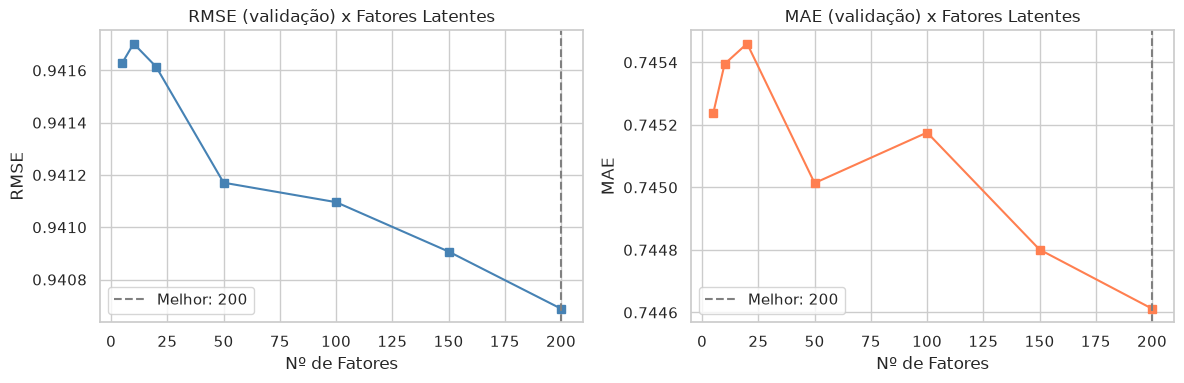

In [ ]:
factors_list = [5, 10, 20, 50, 100, 150, 200]
rmse_val_list, mae_val_list = [], []
for n_factors in factors_list:
    P_, Q_, bu_, bi_, mu_ = train_svd(
        train_data, user2idx, item2idx,
        n_factors=n_factors, lr=0.005, reg=0.02, n_epochs=20, verbose=False
    )
    preds_val = [
        predict_svd(row['user_id'], row['item_id'], P_, Q_, bu_, bi_, mu_, user2idx, item2idx)
        for _, row in val_data.iterrows()
    ]
    rmse_val_list.append(np.sqrt(mean_squared_error(val_data['rating'], preds_val)))
    mae_val_list.append(mean_absolute_error(val_data['rating'], preds_val))
    print(f'Fatores={n_factors:>3} | RMSE val: {rmse_val_list[-1]:.4f} | MAE val: {mae_val_list[-1]:.4f}')
best_factors = factors_list[np.argmin(rmse_val_list)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(factors_list, rmse_val_list, marker='s', color='steelblue')
ax[0].axvline(x=best_factors, color='gray', linestyle='--', label=f'Melhor: {best_factors}')
ax[0].set_title('RMSE (validação) x Fatores Latentes')
ax[0].set_xlabel('Nº de Fatores'); ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[1].plot(factors_list, mae_val_list, marker='s', color='coral')
ax[1].axvline(x=best_factors, color='gray', linestyle='--', label=f'Melhor: {best_factors}')
ax[1].set_title('MAE (validação) x Fatores Latentes')
ax[1].set_xlabel('Nº de Fatores'); ax[1].set_ylabel('MAE')
ax[1].legend()
plt.tight_layout()
plt.savefig('rmse_mae_100k.png', bbox_inches='tight', dpi=150)
plt.show()

### 7.6: Treino com fator latente adequado

In [21]:
print('treinando com 50 fatores latentes...')
P, Q, bu, bi, mu = train_svd(
    train_data, user2idx, item2idx,
    n_factors=50, lr=0.005, reg=0.02, n_epochs=20
)

svd_preds = [
    predict_svd(row['user_id'], row['item_id'], P, Q, bu, bi, mu, user2idx, item2idx)
    for _, row in test_data.iterrows()
]
test_data = test_data.copy()
test_data['svd_predicted'] = svd_preds

rmse_svd = np.sqrt(mean_squared_error(test_data['rating'], test_data['svd_predicted']))
mae_svd  = mean_absolute_error(test_data['rating'], test_data['svd_predicted'])

print('resultado final')
print(f'  Fatores latentes : 50')
print(f'  Learning rate    : 0.005')
print(f'  Regularização    : 0.02')
print(f'  Épocas           : 20')
print(f'  RMSE (teste)     : {rmse_svd:.4f}')
print(f'  MAE  (teste)     : {mae_svd:.4f}')

treinando com 50 fatores latentes...
Época  1/20 | RMSE treino: 1.0584
Época  2/20 | RMSE treino: 0.9941
Época  3/20 | RMSE treino: 0.9702
Época  4/20 | RMSE treino: 0.9572
Época  5/20 | RMSE treino: 0.9489
Época  6/20 | RMSE treino: 0.9429
Época  7/20 | RMSE treino: 0.9384
Época  8/20 | RMSE treino: 0.9349
Época  9/20 | RMSE treino: 0.9321
Época 10/20 | RMSE treino: 0.9298
Época 11/20 | RMSE treino: 0.9279
Época 12/20 | RMSE treino: 0.9262
Época 13/20 | RMSE treino: 0.9248
Época 14/20 | RMSE treino: 0.9236
Época 15/20 | RMSE treino: 0.9224
Época 16/20 | RMSE treino: 0.9214
Época 17/20 | RMSE treino: 0.9205
Época 18/20 | RMSE treino: 0.9196
Época 19/20 | RMSE treino: 0.9187
Época 20/20 | RMSE treino: 0.9179
resultado final
  Fatores latentes : 50
  Learning rate    : 0.005
  Regularização    : 0.02
  Épocas           : 20
  RMSE (teste)     : 0.9445
  MAE  (teste)     : 0.7450


### 7.8: Comparação Final

                 Modelo     RMSE      MAE
   User-Based CF (K=20) 1.015475 0.805448
SVD Regularizado (F=20) 0.944469 0.745037


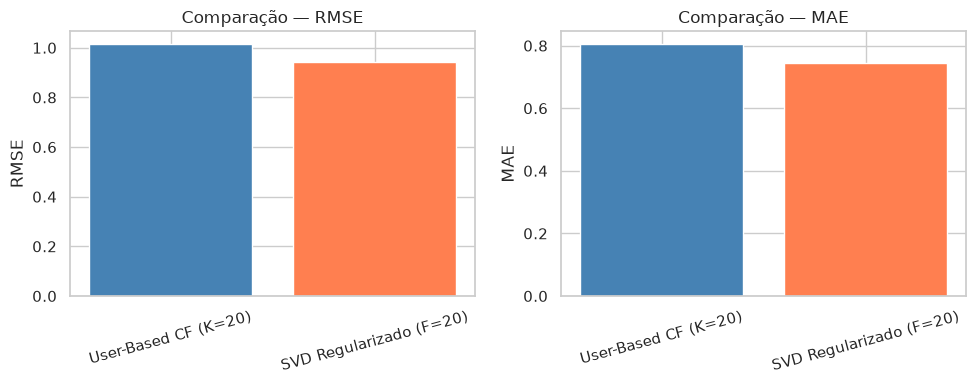

In [28]:
results = pd.DataFrame({
    'Modelo': ['User-Based CF (K=20)', 'SVD Regularizado (F=20)'],
    'RMSE': [rmse, rmse_svd],
    'MAE': [mae, mae_svd]
})
print(results.to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(results['Modelo'], results['RMSE'], color=['steelblue', 'coral'], edgecolor='white')
ax[0].set_title('Comparação — RMSE'); ax[0].set_ylabel('RMSE')
ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(results['Modelo'], results['MAE'], color=['steelblue', 'coral'], edgecolor='white')
ax[1].set_title('Comparação — MAE'); ax[1].set_ylabel('MAE')
ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('comparacao_100k.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Benchmarking

### 8.1: Classificar Filmes por Popularidade

In [23]:
ratings_per_item = train_data.groupby('item_id').size().rename('n_ratings')

popular_threshold = ratings_per_item.quantile(0.80)
rare_threshold = ratings_per_item.quantile(0.20)

popular_items = ratings_per_item[ratings_per_item >= popular_threshold].index
rare_items = ratings_per_item[ratings_per_item <= rare_threshold].index

print(f'Limiar popular : >= {popular_threshold:.0f} avaliações')
print(f'Limiar raro : <= {rare_threshold:.0f} avaliações')
print(f'Filmes populares: {len(popular_items):,}')
print(f'Filmes raros : {len(rare_items):,}')

Limiar popular : >= 66 avaliações
Limiar raro : <= 4 avaliações
Filmes populares: 325
Filmes raros : 386


### 8.2: Separar Conjunto de Teste

In [24]:
test_popular = test_data[test_data['item_id'].isin(popular_items)].copy()
test_rare = test_data[test_data['item_id'].isin(rare_items)].copy()

print(f'Amostras de teste — populares: {len(test_popular):,}')
print(f'Amostras de teste — raros : {len(test_rare):,}')

Amostras de teste — populares: 12,544
Amostras de teste — raros : 297


### 8.3: Função Auxiliar de Métricas

In [25]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

rmse_svd_pop, mae_svd_pop = evaluate(test_popular['rating'], test_popular['svd_predicted'])
rmse_svd_rare, mae_svd_rare = evaluate(test_rare['rating'], test_rare['svd_predicted'])

print('SVD REGULARIZADO')
print(f' Populares | RMSE: {rmse_svd_pop:.4f} | MAE: {mae_svd_pop:.4f}')
print(f' Raros | RMSE: {rmse_svd_rare:.4f} | MAE: {mae_svd_rare:.4f}')

rmse_ub_pop, mae_ub_pop = evaluate(test_popular['rating'], test_popular['predicted'])
rmse_ub_rare, mae_ub_rare = evaluate(test_rare['rating'], test_rare['predicted'])

print('USER-BASED CF')
print(f' Populares | RMSE: {rmse_ub_pop:.4f} | MAE: {mae_ub_pop:.4f}')
print(f' Raros | RMSE: {rmse_ub_rare:.4f} | MAE: {mae_ub_rare:.4f}')

SVD REGULARIZADO
 Populares | RMSE: 0.9223 | MAE: 0.7263
 Raros | RMSE: 1.1308 | MAE: 0.9140
USER-BASED CF
 Populares | RMSE: 0.9651 | MAE: 0.7654
 Raros | RMSE: 1.5731 | MAE: 1.2393


### 8.4: Tabela Comparativa Consolidada

In [26]:
bench = pd.DataFrame({
    'Modelo' : ['User-Based CF', 'User-Based CF', 'SVD Regularizado', 'SVD Regularizado'],
    'Cenário' : ['Populares', 'Raros', 'Populares', 'Raros'],
    'RMSE' : [rmse_ub_pop, rmse_ub_rare, rmse_svd_pop, rmse_svd_rare],
    'MAE' : [mae_ub_pop, mae_ub_rare, mae_svd_pop, mae_svd_rare],
})

print(bench.to_string(index=False))

          Modelo   Cenário     RMSE      MAE
   User-Based CF Populares 0.965069 0.765385
   User-Based CF     Raros 1.573080 1.239314
SVD Regularizado Populares 0.922268 0.726256
SVD Regularizado     Raros 1.130827 0.914012


### 8.5: Visualização do benchmarking

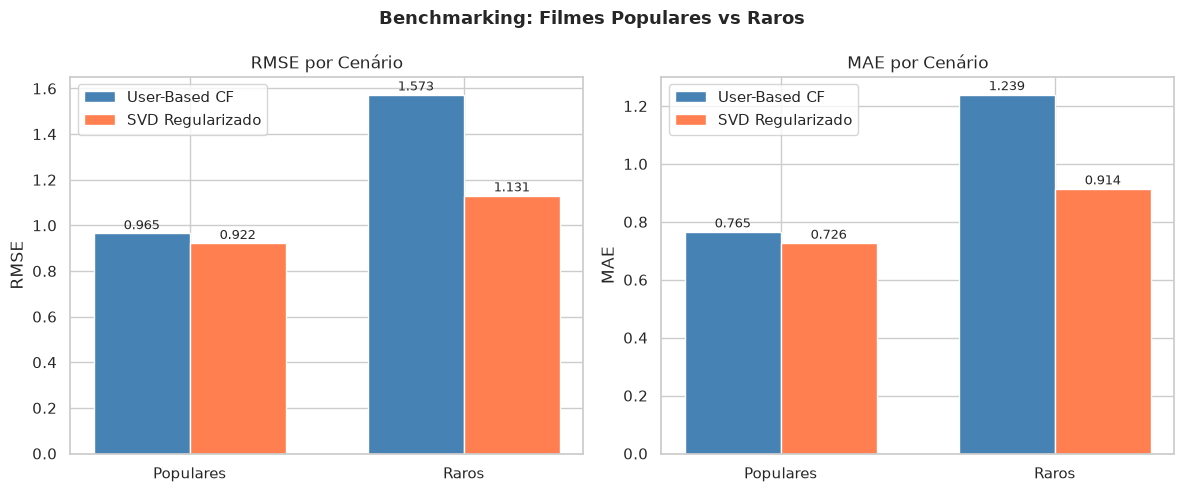

In [27]:
bench = pd.DataFrame({
    'Modelo'  : ['User-Based CF', 'User-Based CF', 'SVD Regularizado', 'SVD Regularizado'],
    'Cenário' : ['Populares', 'Raros', 'Populares', 'Raros'],
    'RMSE'    : [rmse_ub_pop, rmse_ub_rare, rmse_svd_pop, rmse_svd_rare],
    'MAE'     : [mae_ub_pop,  mae_ub_rare,  mae_svd_pop,  mae_svd_rare],
})

cenarios = ['Populares', 'Raros']
x = np.arange(len(cenarios))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    ub_vals  = bench[bench['Modelo'] == 'User-Based CF'][metric].values
    svd_vals = bench[bench['Modelo'] == 'SVD Regularizado'][metric].values

    bars1 = ax.bar(x - width/2, ub_vals,  width, label='User-Based CF',     color='steelblue', edgecolor='white')
    bars2 = ax.bar(x + width/2, svd_vals, width, label='SVD Regularizado',  color='coral',     edgecolor='white')

    ax.set_title(f'{metric} por Cenário')
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(cenarios)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Benchmarking: Filmes Populares vs Raros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmarking.png', bbox_inches='tight')
plt.show()